# Visualization Notebook for InflationEasy
This notebook demonstrates how to load and visualize the output data generated by the InflationEasy lattice simulation code.
It covers the evolution of the inflaton field, power spectra of curvature perturbations, probability distribution functions (PDFs), and 2D snapshots of the field.

Note: outputs are generated in reduced Planck mass units $M^{\rm reduced}_{\rm Pl}=\frac{M_{\rm Pl}}{\sqrt{8\pi}}=1$, and the scale factor is set to $a=1$ at the beginning of the simulation, which is used to define the comoving momentum.

## 1. Importing Required Libraries
We begin by importing the necessary Python libraries and setting up the plotting style.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.colors import Normalize
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Set LaTeX rendering and font for consistent plots
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "DejaVu Sans"
})

## 2. Loading Simulation Data
Reading the output files.

In [ ]:
# Define path to results
path = '/results/'


# Load simulation data
s = np.loadtxt(path + 'spectra.dat')
sN = np.loadtxt(path + 'spectraN.dat')
modes_data = np.loadtxt(path + 'modes.dat')
k_list = modes_data[:, 0] if modes_data.ndim == 2 else modes_data
Nk_list = modes_data[:, 1] if modes_data.ndim == 2 else None
st = np.loadtxt(path + 'spectratimes.dat')
f = np.loadtxt(path + 'means.dat')
fv = np.loadtxt(path + 'velocity.dat')
var = np.loadtxt(path + 'variance.dat')
sf = np.loadtxt(path + 'sf.dat')
sh = np.loadtxt(path + 'histogram.dat')
sh_zeta = np.loadtxt(path + 'histogramN.dat')
sht = np.loadtxt(path + 'histogramtimes.dat')
sht_zeta = np.loadtxt(path + 'histogramtimesN.dat')

nFields = 2

## 3. Inflaton Mean and Velocity
We analyze how the mean inflaton field $\langle\phi\rangle$ and its velocity $\langle\dot\phi\rangle$ evolve during the simulation.

Critical phi: 0.014142135623730952, closest value at N=1.03 with phi=0.014142
Difference from critical phi: -2.1342948935965111e-10


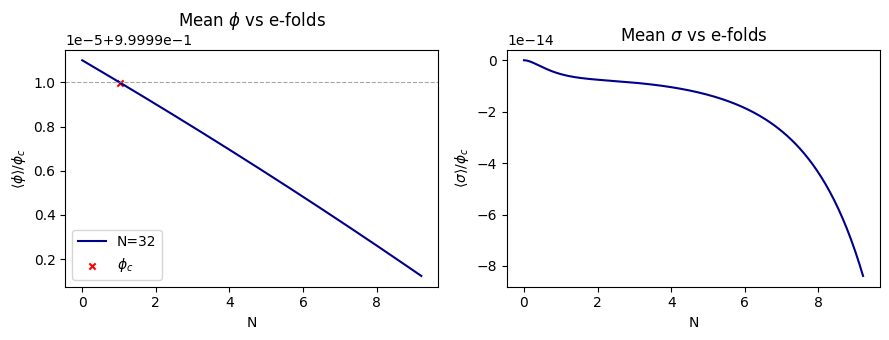

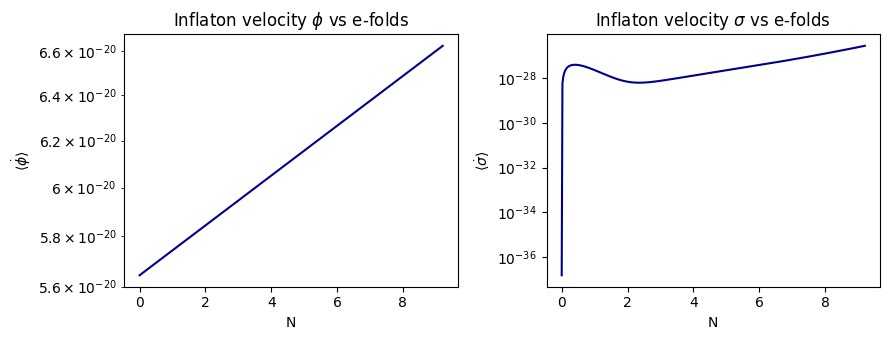

In [3]:
# Plot the time evolution of the inflaton mean value, normalized by the critical field value
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
fields = ['\phi', '\sigma']
axes = np.atleast_1d(axes)
phi_c = np.sqrt(2) * 0.01

for n in range(nFields):
    ax = axes[n]
    mean_norm = f[:, n + 2] / phi_c
    ax.plot(np.log(sf[:, 1]), mean_norm, color='darkblue', label='N=32')
    #ax.plot(np.log(sf2[:, 1]), f2[:, n + 2] / phi_c, color='orange', linestyle='--', label='N=32')
    ax.set_ylabel(rf"$\langle {fields[n]} \rangle / \phi_c$")
    ax.set_xlabel("N")
    ax.set_title(rf"Mean ${fields[n]}$ vs e-folds")
    if n == 0:
        idx = np.argmin(np.abs(f[:, n + 2] - phi_c))
        #idx2 = np.argmin(np.abs(f2[:, n + 2] - phi_c))
        print(f"Critical phi: {phi_c}, closest value at N={np.log(sf[idx, 1]):.2f} with phi={f[idx, n + 2]:.6f}")
        print(f"Difference from critical phi: {f[idx, n + 2] - phi_c}")
        ax.scatter(np.log(sf[idx, 1]), mean_norm[idx], color='red', label=r'$\phi_c$', marker='x', s=20)
        #ax.scatter(np.log(sf2[idx2, 1]), f2[idx2, n + 2] / phi_c, color='green', label=r'$\phi_c$ (N=32)', marker='x', s=20)
        ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
        ax.legend()

plt.tight_layout()
plt.show()

# Plot the velocity of the inflaton field
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

for n in range(nFields):
    ax = axes[n]
    ax.semilogy(np.log(sf[:, 1]), np.abs(fv[:, n+2]), color='darkblue')
    ax.set_ylabel(rf"$\langle\dot{{{fields[n]}}}\rangle$")
    ax.set_xlabel("N")
    ax.set_title(rf"Inflaton velocity ${fields[n]}$ vs e-folds")

plt.tight_layout()
plt.show()



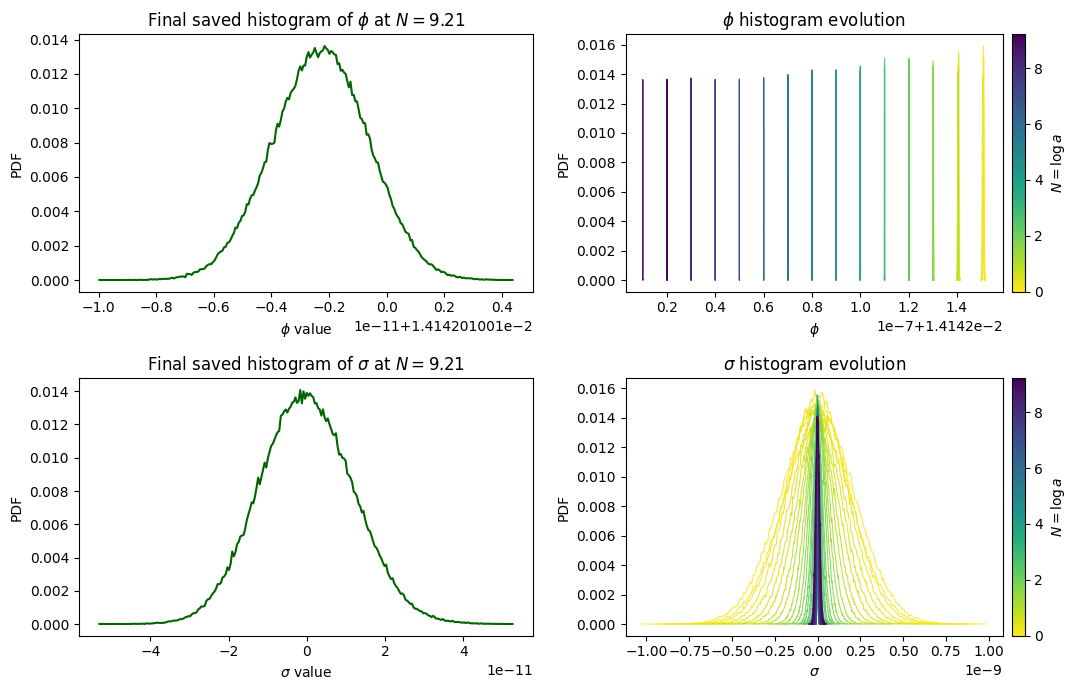

In [4]:
from pathlib import Path


def load_histogram_blocks(hist_file, times_file):
    hist_times = np.atleast_2d(np.loadtxt(times_file))
    with open(hist_file, 'r', encoding='utf-8') as fh:
        hist_blocks = [
            np.array([float(x) for x in block.splitlines()], dtype=float)
            for block in fh.read().strip().split('\n\n')
            if block.strip()
        ]
    n_hist = min(len(hist_blocks), len(hist_times))
    return hist_blocks[:n_hist], hist_times[:n_hist]


base_path = Path(path)
field_specs = []

if nFields == 1:
    field_specs.append((0, r'$\phi$', base_path / 'histogram.dat', base_path / 'histogramtimes.dat'))
else:
    field_specs.append((0, r'$\phi$', base_path / 'histogram_field0.dat', base_path / 'histogramtimes_field0.dat'))
    field_specs.append((1, r'$\sigma$', base_path / 'histogram_field1.dat', base_path / 'histogramtimes_field1.dat'))

fig, axes = plt.subplots(len(field_specs), 2, figsize=(11, 3.5 * len(field_specs)))
axes = np.atleast_2d(axes)

for row, (field_idx, field_label, hist_file, times_file) in enumerate(field_specs):
    if not hist_file.exists() or not times_file.exists():
        continue

    hist_blocks, hist_times = load_histogram_blocks(hist_file, times_file)
    if len(hist_blocks) == 0:
        continue

    last_hist = hist_blocks[-1]
    _, a_last, bmin_last, df_last = hist_times[-1, :4]
    bins_last = bmin_last + (np.arange(len(last_hist)) + 0.5) * df_last

    ax_main = axes[row, 0]
    ax_main.plot(bins_last, last_hist, color='darkgreen', lw=1.5)
    ax_main.set_xlabel(rf'{field_label} value')
    ax_main.set_ylabel(r'PDF')
    ax_main.set_title(rf'Final saved histogram of {field_label} at $N={np.log(a_last):.2f}$')

    cmap = cm.viridis_r
    idxs = np.linspace(0, len(hist_blocks) - 1, min(50, len(hist_blocks)), dtype=int)
    norm_hist = mcolors.Normalize(vmin=np.log(hist_times[idxs, 1]).min(), vmax=np.log(hist_times[idxs, 1]).max())

    ax_evo = axes[row, 1]
    for idx in idxs:
        block = hist_blocks[idx]
        _, a_i, bmin_i, df_i = hist_times[idx, :4]
        bins_i = bmin_i + (np.arange(len(block)) + 0.5) * df_i
        ax_evo.plot(bins_i, block, color=cmap(norm_hist(np.log(a_i))), lw=0.8, alpha=0.9)

    sm_hist = cm.ScalarMappable(norm=norm_hist, cmap=cmap)
    cbar = fig.colorbar(sm_hist, ax=ax_evo, pad=0.02)
    cbar.set_label(r'$N = \log a$')
    ax_evo.set_xlabel(rf'{field_label}')
    ax_evo.set_ylabel(r'PDF')
    ax_evo.set_title(rf'{field_label} histogram evolution')

plt.tight_layout()
plt.show()

In [5]:
# Variance of the initial field distribution (from the first saved histogram)

for n in range(nFields):

    if n == 1:
        sigma_hist_path = base_path / 'histogram_field1.dat'
        sigma_hist_times_path = base_path / 'histogramtimes_field1.dat'
    else:
        sigma_hist_path = base_path / 'histogram_field0.dat'
        sigma_hist_times_path = base_path / 'histogramtimes_field0.dat'
    if sigma_hist_path.exists() and sigma_hist_times_path.exists():
        hist_path = sigma_hist_path
        hist_times_path = sigma_hist_times_path

    hist_blocks, hist_times = load_histogram_blocks(hist_path, hist_times_path)

    hist_label = r'$\phi$' if n == 0 else r'$\sigma$'
    if "hist_blocks" in globals() and "hist_times" in globals() and len(hist_blocks) > 0:
        h0 = np.asarray(hist_blocks[2], dtype=float)
        t0, a0, bmin0, db0 = np.asarray(hist_times[2], dtype=float)[:4]
    else:
        # Fallback: rebuild first histogram block from flattened arrays
        n_bins = len(sh) // len(sht)
        h0 = np.asarray(sh[:n_bins], dtype=float)
        t0, a0, bmin0, db0 = np.asarray(sht[0], dtype=float)[:4]

    x0 = bmin0 + (np.arange(len(h0)) + 0.5) * db0
    pdf0 = np.clip(h0, 0.0, None)

    norm0 = np.trapezoid(pdf0, x0)
    if norm0 <= 0:
        raise ValueError("Initial histogram is empty; cannot compute variance.")

    pdf0 /= norm0
    mean0 = np.trapezoid(x0 * pdf0, x0)
    var0 = np.trapezoid((x0 - mean0) ** 2 * pdf0, x0)

    print(f"Field {hist_label}:")
    print(f"    Initial histogram time t = {t0:.6f}, N = log(a) = {np.log(a0):.6f}")
    print(f"    Initial mean            = {mean0:.6e}")
    print(f"    Initial variance        = {var0:.6e}")
    print(f"    Initial std             = {np.sqrt(var0):.6e}")

Field $\phi$:
    Initial histogram time t = 0.076200, N = log(a) = 0.044992
    Initial mean            = 1.414215e-02
    Initial variance        = 4.259523e-20
    Initial std             = 2.063861e-10
Field $\sigma$:
    Initial histogram time t = 0.076200, N = log(a) = 0.044992
    Initial mean            = -3.890890e-15
    Initial variance        = 4.270023e-20
    Initial std             = 2.066403e-10


## 4. Power Spectra

We compare the power spectrum of $\zeta$ using both the linear and the $\delta N$ approach.

In [6]:
# Inputs from your notebook
phi_mean = f[:, 2]          # <phi>
N_arr = np.log(sf[:, 1])    # e-folds
a_arr = sf[:, 1]            # scale factor
H_arr = sf[:, 2]            # Hubble (as used elsewhere in your notebook)

# Use your chosen critical value
# phi_c = 0.1

# First crossing index (phi goes below phi_c)
idx = np.where(phi_mean <= phi_c)[0]
# if len(idx) == 0:
#     raise ValueError("No critical crossing found: phi never goes below phi_c.")
i1 = idx[0]
i0 = max(i1 - 1, 0)

# Linear interpolation to get a smoother crossing estimate
phi0, phi1 = phi_mean[i0], phi_mean[i1]
if phi1 == phi0:
    w = 1.0
else:
    w = (phi_c - phi0) / (phi1 - phi0)
w = np.clip(w, 0.0, 1.0)

N_c = N_arr[i0] + w * (N_arr[i1] - N_arr[i0])
a_c = a_arr[i0] + w * (a_arr[i1] - a_arr[i0])
H_c = H_arr[i0] + w * (H_arr[i1] - H_arr[i0])

k_c = a_c * H_c

# Closest simulated mode
k_mode = k_list[np.argmin(np.abs(k_list - k_c))]

print(f"N_c  = {N_c:.6f}")
print(f"a_c  = {a_c:.6e}")
print(f"H_c  = {H_c:.6e}")
print(f"k_c  = a_c H_c = {k_c:.6e}")
print(f"nearest grid mode = {k_mode:.6e}")
print(f"relative mismatch = {abs(k_mode-k_c)/k_c:.3e}")

N_c  = 1.014669
a_c  = 2.759333e+00
H_c  = 4.085100e-12
k_c  = a_c H_c = 1.127215e-11
nearest grid mode = 0.000000e+00
relative mismatch = 1.000e+00


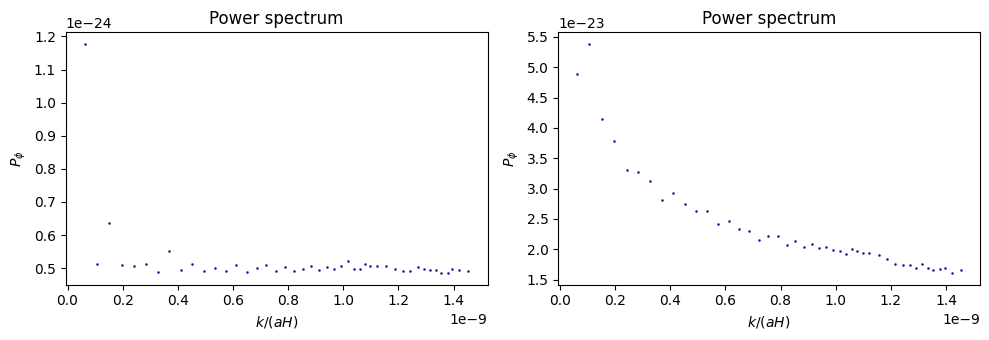

In [7]:
fig, axes = plt.subplots(1, nFields, figsize=(5 * nFields, 3.5))
axes = np.atleast_1d(axes)


cutoff_i = len(k_list) - 10
lowcutoff_i = 1

for n in range(nFields):
    spectrum_list = [s[i:i+len(k_list), 2+n] for i in range(0, len(s[:, 0]), len(k_list))]
    modes_list = [s[i:i+len(k_list), 0] for i in range(0, len(s[:, 0]), len(k_list))]
    field = fields[n] if n < len(fields) else rf'\phi_{{{n+1}}}'
    ax = axes[n]

    #k_plot = modes_list[-1][lowcutoff_i:cutoff_i]
    k_plot = k_list[lowcutoff_i:cutoff_i]
    p_plot = spectrum_list[-1][lowcutoff_i:cutoff_i] * k_plot**3 / (2 * np.pi**2) 
    mask = k_plot > 0
    ax.scatter(k_plot[mask], p_plot[mask], color='darkblue', s=0.8, alpha=0.8)
    # ax.set_xscale('log')
    # ax.set_yscale('log')
    #ax.axvline(k_c, color="red", ls="--", lw=1.2, label=r"$k_c=a_cH_c$")
    ax.set_ylabel(rf'$ P_\phi$')
    ax.set_xlabel(rf'$k/(aH)$')
    ax.set_title("Power spectrum")
    #ax.legend()

plt.tight_layout()
plt.show()

# Need 2*10^-11 for zeta

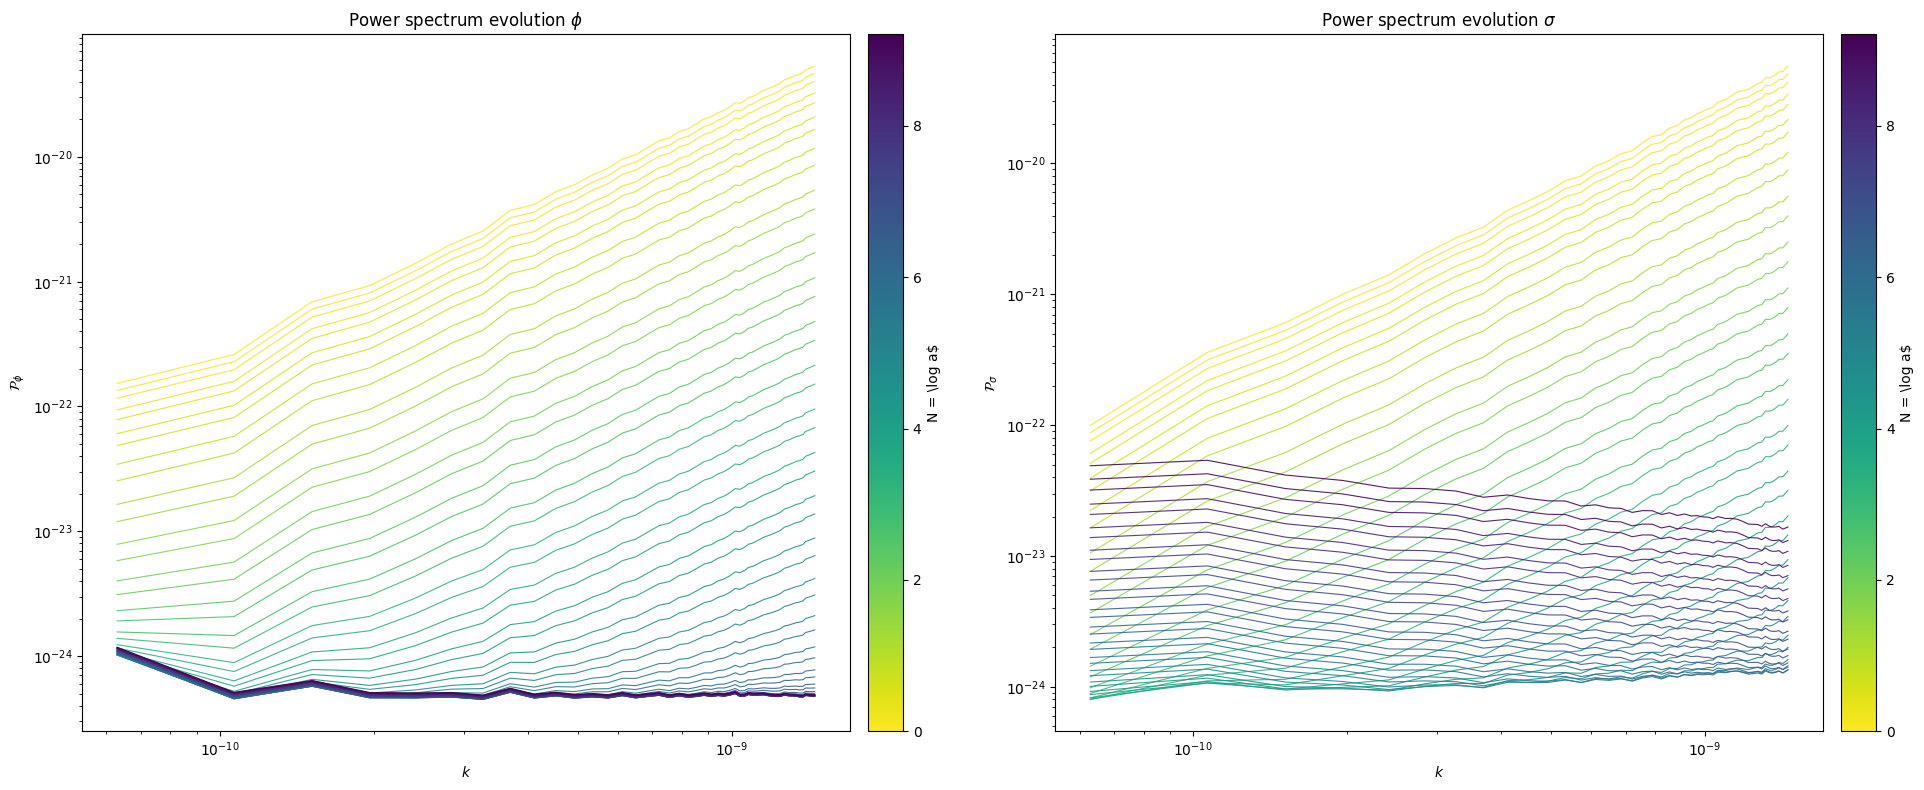

In [8]:
# Plot spectrum evolution over time for s1 and s2
fig, axes = plt.subplots(1, nFields, figsize=(10 * nFields, 8))
axes = np.atleast_1d(axes)

for n in range(nFields):
    spectrum_list = [s[i:i+len(k_list), 2+n] for i in range(0, len(s[:, 0]), len(k_list))]

    # Slice and mask k to avoid log10(0) errors
    cutoff_i = len(k_list) - 10
    lowcutoff_i = 1
    k_vals = k_list[lowcutoff_i:cutoff_i] # Normalize by final Hubble
    mask = k_vals > 0
    k_vals = k_vals[mask]

    # Plot 20 evenly distributed spectra
    n_steps = len(spectrum_list)
    num_to_plot = min(50, n_steps)
    time_indices = np.linspace(0, n_steps - 1, num_to_plot, dtype=int)

    # Compute e-folds N = log(a) at each index
    efolds = np.log(sf[:, 1])
    efolds_to_plot = efolds[time_indices]

    # Normalize for colormap based on e-folds
    norm = mcolors.Normalize(vmin=efolds_to_plot.min(), vmax=efolds_to_plot.max())
    cmap = cm.viridis_r
    sm = cm.ScalarMappable(norm=norm, cmap=cmap)

    # Plot each spectrum snapshot
    field = fields[n] if n < len(fields) else rf'\phi_{{{n+1}}}'
    ax = axes[n]
    for t_idx, N in zip(time_indices, efolds_to_plot):
        spectrum = spectrum_list[t_idx][lowcutoff_i:cutoff_i][mask]
        power = spectrum * k_vals**3 / (2 * np.pi**2)
        ax.loglog(k_vals, power, color=cmap(norm(N)), lw=0.8, alpha=0.9)
        ax.set_title(rf"Power spectrum evolution ${fields[n]}$")
        ax.set_ylabel(rf'$\mathcal{{P}}_{{{fields[n]}}}$')

    # Axis labels
    ax.set_xlabel('$k$')
    #ax.set_xlim(0, 100)

    # Colorbar labeled by number of e-folds
    cbar = fig.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label('N = \log a$')

fig.tight_layout()
plt.show()
